In [1]:
# ============================================
# 1. Imports
# ============================================
import re
import os
import html
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from collections import Counter
from itertools import product

import hdbscan
import umap
from datasets import load_dataset, load_from_disk
from sentence_transformers import SentenceTransformer
from sklearn.metrics import silhouette_score
from sklearn.feature_extraction.text import CountVectorizer, ENGLISH_STOP_WORDS
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# Optional: UMAP is often better than PCA/t-SNE for embeddings, but requires install
# !pip install umap-learn
# import umap


# ============================================
# 2. Configuration
# ============================================
DATASET_NAME = os.path.abspath("../dataset/full_text_and_sentiment")   # e.g. "csv" or local HF dataset path
DATASET_SPLIT = "train"                            # change if needed
TEXT_COL = "text"

EMBEDDING_MODEL_NAME = "all-distilroberta-v1"

# Preprocessing
REMOVE_URLS = True
REMOVE_MENTIONS = True
NORMALIZE_WHITESPACE = True
LOWERCASE = True
REMOVE_RT = True
KEEP_HASHTAG_TEXT = True     # "#AI" -> "AI" instead of removing entire token
REMOVE_EMOJIS = False        # often useful signal; keep unless you want cleaner topic text
REMOVE_DUPLICATES = True
MIN_CHARS = 3                # filter very short texts after preprocessing

# Clustering
RANDOM_STATE = 42
N_COMPONENTS = [5, 10, 15, 30, 50]
MIN_CLUSTER_SIZE = [50, 100, 150, 200, 250, 300]
MIN_SAMPLES = [5, 15, 25, 50]

# HDBSCAN settings
CLUSTER_SELECTION_METHOD = "eom"
ALLOW_SINGLE_CLUSTER = False
USE_PCA_BEFORE_HDBSCAN = False
USE_UMAP_BEFORE_HDBSCAN = True

# Objective function during parameter search
NOISE_PENALTY = 0.15

# Embedding / batching
BATCH_SIZE = 128
SHOW_PROGRESS_BAR = True

# Optional dimensionality reduction before clustering
PCA_DIM = 50

# Inspection
N_REPRESENTATIVE_TWEETS = 10
TOP_TERMS_PER_CLUSTER = 15
TOP_NGRAM_RANGE = (1, 2)
TOP_TERMS_MAX_FEATURES = 5000
TOP_TERMS_MAX_DF = 0.7

# Dynamic stopword filtering for very common dataset words
ENABLE_DYNAMIC_STOPWORDS = True
COMMON_WORD_TOP_N = 120
COMMON_WORD_MIN_DOC_FRAC = 0.15

# Include noise cluster (-1) in term summaries
INCLUDE_NOISE_IN_SUMMARY = False

# Visualization
VIS_SAMPLE_SIZE = 3000       # subsample for t-SNE if dataset is large

In [2]:
# ============================================
# 3. Load dataset
# ============================================
# Example 1: loading a named HF dataset
# dataset = load_dataset(DATASET_NAME)

# Example 2: loading a local dataset from disk
# from datasets import load_from_disk
# dataset = load_from_disk(DATASET_NAME)

# Replace this section based on your actual setup:
dataset = load_from_disk(DATASET_NAME)

# If dataset is a DatasetDict, select split
# hf_split = dataset[DATASET_SPLIT]
hf_split = dataset
orig_size = hf_split.num_rows

print(hf_split)
print(hf_split.column_names)
print(f"Original size: {orig_size}")

Dataset({
    features: ['textID', 'text', 'sentiment'],
    num_rows: 31014
})
['textID', 'text', 'sentiment']
Original size: 31014


In [3]:
# ============================================
# 4. Preprocessing functions
# ============================================
URL_PATTERN = re.compile(r"https?://\S+|www\.\S+")
MENTION_PATTERN = re.compile(r"@\w+")
HASHTAG_PATTERN = re.compile(r"#(\w+)")
RT_PATTERN = re.compile(r"^rt\s+", re.IGNORECASE)
WHITESPACE_PATTERN = re.compile(r"\s+")

# Basic emoji range removal if needed
EMOJI_PATTERN = re.compile(
    "["
    "\U0001F600-\U0001F64F"  # emoticons
    "\U0001F300-\U0001F5FF"  # symbols & pictographs
    "\U0001F680-\U0001F6FF"  # transport & map
    "\U0001F1E0-\U0001F1FF"  # flags
    "\U00002700-\U000027BF"
    "\U000024C2-\U0001F251"
    "]+",
    flags=re.UNICODE
)

def preprocess_tweet(text: str) -> str:
    """Basic tweet cleaning for clustering/topic discovery."""
    if text is None:
        return ""

    text = str(text)
    text = html.unescape(text)

    if LOWERCASE:
        text = text.lower()

    if REMOVE_RT:
        text = RT_PATTERN.sub("", text)

    if REMOVE_URLS:
        text = URL_PATTERN.sub(" ", text)

    if REMOVE_MENTIONS:
        text = MENTION_PATTERN.sub(" ", text)

    if KEEP_HASHTAG_TEXT:
        # Convert #AI -> AI
        text = HASHTAG_PATTERN.sub(r"\1", text)
    else:
        text = HASHTAG_PATTERN.sub(" ", text)

    if REMOVE_EMOJIS:
        text = EMOJI_PATTERN.sub(" ", text)

    if NORMALIZE_WHITESPACE:
        text = WHITESPACE_PATTERN.sub(" ", text).strip()

    return text

In [4]:
# ============================================
# 5. Convert HF dataset to DataFrame and clean
# ============================================
df = hf_split.to_pandas()

assert TEXT_COL in df.columns, f"Column '{TEXT_COL}' not found in dataset."

# df = df[[TEXT_COL]].copy()
df["raw_text"] = df[TEXT_COL].astype(str)
df["clean_text"] = df["raw_text"].apply(preprocess_tweet)

# Filter empty / too-short texts
df = df[df["clean_text"].str.len() >= MIN_CHARS].copy()

if REMOVE_DUPLICATES:
    df = df.drop_duplicates(subset=["clean_text"]).copy()

df = df.reset_index(drop=True)

num_dropped = orig_size - len(df)
print(f"Number of usable tweets: {len(df)}")
print(f"Number of tweets dropped: {num_dropped}")
df.head()

Number of usable tweets: 30889
Number of tweets dropped: 125


,textID,text,sentiment,raw_text,clean_text
0,cb774db0d1,"I`d have responded, if I were going",neutral,"I`d have responded, if I were going","i`d have responded, if i were going"
1,549e992a42,Sooo SAD I will miss you here in San Diego!!!,negative,Sooo SAD I will miss you here in San Diego!!!,sooo sad i will miss you here in san diego!!!
2,088c60f138,my boss is bullying me...,negative,my boss is bullying me...,my boss is bullying me...
3,9642c003ef,what interview! leave me alone,negative,what interview! leave me alone,what interview! leave me alone
4,358bd9e861,"Sons of ****, why couldn`t they put them on t...",negative,"Sons of ****, why couldn`t they put them on t...","sons of ****, why couldn`t they put them on th..."


In [5]:
# ============================================
# 6. Load sentence embedding model
# ============================================
model = SentenceTransformer(EMBEDDING_MODEL_NAME)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: sentence-transformers/all-distilroberta-v1
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [6]:
# ============================================
# 7. Generate sentence embeddings
# ============================================
texts = df["clean_text"].tolist()

embeddings = model.encode(
    texts,
    batch_size=BATCH_SIZE,
    show_progress_bar=SHOW_PROGRESS_BAR,
    convert_to_numpy=True,
    normalize_embeddings=True  # often helpful for clustering cosine-like structure
)

print("Embeddings shape:", embeddings.shape)

Batches:   0%|          | 0/242 [00:00<?, ?it/s]

Embeddings shape: (30889, 768)


In [7]:
# ============================================
# 8. Optional PCA before clustering
# ============================================
X = embeddings

if USE_UMAP_BEFORE_HDBSCAN:
    umap_ = umap.UMAP(n_components=max(N_COMPONENTS), metric='cosine', random_state=RANDOM_STATE)
    X = umap_.fit_transform(embeddings)
    print("Reduced shape after UMAP:", X.shape)
elif USE_PCA_BEFORE_HDBSCAN:
    pca = PCA(n_components=max(N_COMPONENTS), random_state=RANDOM_STATE)
    X = pca.fit_transform(embeddings)
    print("Reduced shape after PCA:", X.shape)
else:
    print("Using original embedding space:", X.shape)

c:\repos\cs4248-tutorials\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Reduced shape after UMAP: (30889, 50)


In [8]:
# ============================================
# 9. HDBSCAN parameter search
# ============================================
def evaluate_hdbscan_params(
    X,
    n_components_list,
    min_cluster_size_list,
    min_samples_list,
    random_state=42,
    cluster_selection_method="eom",
    allow_single_cluster=False,
    noise_penalty=0.15,
):
    """
    Evaluate HDBSCAN across a parameter grid.

    Scoring objective:
    objective = silhouette(non-noise points) - noise_penalty * noise_ratio

    Notes:
    - Silhouette is computed only on non-noise points and only when >= 2 clusters exist.
    - Higher objective is better.
    """
    rows = []

    for n_comp, min_cs, min_s in product(n_components_list, min_cluster_size_list, min_samples_list):
        print(
            f"Evaluating n_components={n_comp}, "
            f"min_cluster_size={min_cs}, min_samples={min_s}"
        )

        X_eval = X[:, :n_comp] if X.shape[1] > n_comp else X

        clusterer = hdbscan.HDBSCAN(
            min_cluster_size=min_cs,
            min_samples=min_s,
            metric="euclidean",
            cluster_selection_method=cluster_selection_method,
            prediction_data=False,
            core_dist_n_jobs=-1,
            approx_min_span_tree=True,
            allow_single_cluster=allow_single_cluster,
        )

        labels = clusterer.fit_predict(X_eval)

        noise_mask = labels == -1
        non_noise_mask = ~noise_mask
        noise_ratio = float(noise_mask.mean())

        unique_clusters = np.unique(labels[non_noise_mask]) if non_noise_mask.any() else np.array([])
        n_clusters = int(len(unique_clusters))

        sil = np.nan
        if n_clusters >= 2 and non_noise_mask.sum() >= 3:
            sil = silhouette_score(X_eval[non_noise_mask], labels[non_noise_mask])

        stability = float(clusterer.relative_validity_) if hasattr(clusterer, "relative_validity_") else np.nan

        objective = (-noise_penalty * noise_ratio) if np.isnan(sil) else (sil - noise_penalty * noise_ratio)

        rows.append(
            {
                "n_components": n_comp,
                "min_cluster_size": min_cs,
                "min_samples": min_s,
                "n_clusters": n_clusters,
                "noise_ratio": noise_ratio,
                "silhouette_non_noise": sil,
                "hdbscan_relative_validity": stability,
                "objective": objective,
            }
        )

    return pd.DataFrame(rows)


results_df = evaluate_hdbscan_params(
    X,
    n_components_list=N_COMPONENTS,
    min_cluster_size_list=MIN_CLUSTER_SIZE,
    min_samples_list=MIN_SAMPLES,
    random_state=RANDOM_STATE,
    cluster_selection_method=CLUSTER_SELECTION_METHOD,
    allow_single_cluster=ALLOW_SINGLE_CLUSTER,
    noise_penalty=NOISE_PENALTY,
)

results_df = results_df.sort_values("objective", ascending=False).reset_index(drop=True)
results_df.head(20)

Evaluating n_components=5, min_cluster_size=50, min_samples=5
Evaluating n_components=5, min_cluster_size=50, min_samples=15
Evaluating n_components=5, min_cluster_size=50, min_samples=25
Evaluating n_components=5, min_cluster_size=50, min_samples=50
Evaluating n_components=5, min_cluster_size=100, min_samples=5
Evaluating n_components=5, min_cluster_size=100, min_samples=15
Evaluating n_components=5, min_cluster_size=100, min_samples=25
Evaluating n_components=5, min_cluster_size=100, min_samples=50
Evaluating n_components=5, min_cluster_size=150, min_samples=5
Evaluating n_components=5, min_cluster_size=150, min_samples=15
Evaluating n_components=5, min_cluster_size=150, min_samples=25
Evaluating n_components=5, min_cluster_size=150, min_samples=50
Evaluating n_components=5, min_cluster_size=200, min_samples=5
Evaluating n_components=5, min_cluster_size=200, min_samples=15
Evaluating n_components=5, min_cluster_size=200, min_samples=25
Evaluating n_components=5, min_cluster_size=200,

,n_components,min_cluster_size,min_samples,n_clusters,noise_ratio,silhouette_non_noise,hdbscan_relative_validity,objective
0,30,100,50,33,0.535822,0.562837,NaN,0.482464
1,30,50,50,46,0.535822,0.560095,NaN,0.479722
2,15,100,50,34,0.518340,0.550255,NaN,0.472504
3,30,150,50,27,0.520930,0.548159,NaN,0.470020
4,15,150,15,28,0.539351,0.548037,NaN,0.467134
5,10,150,25,29,0.518631,0.544805,NaN,0.467010
6,15,50,50,44,0.510700,0.540574,NaN,0.463969
7,50,150,15,28,0.539221,0.544125,NaN,0.463242
8,15,150,25,29,0.512189,0.538926,NaN,0.462098
9,10,100,25,40,0.526628,0.540178,NaN,0.461183


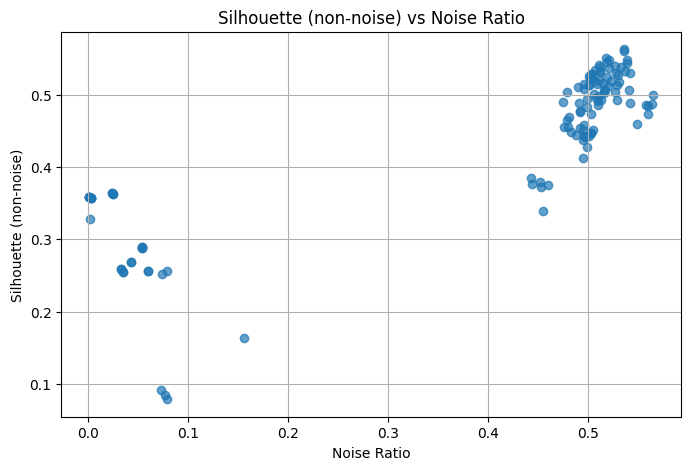

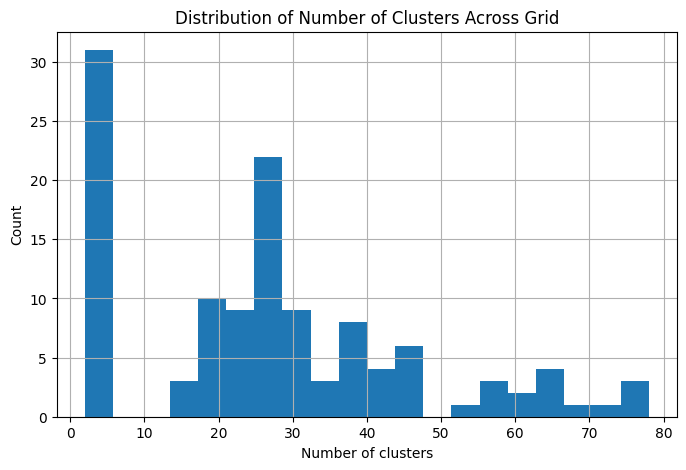

Best parameters by objective:
n_components             30.000000
min_cluster_size        100.000000
min_samples              50.000000
n_clusters               33.000000
noise_ratio               0.535822
silhouette_non_noise      0.562837
objective                 0.482464
Name: 0, dtype: float64


In [10]:
# ============================================
# 10. Inspect parameter-search results
# ============================================
fig, ax = plt.subplots(figsize=(8, 5))
plot_df = results_df.dropna(subset=["silhouette_non_noise"])
if not plot_df.empty:
    ax.scatter(plot_df["noise_ratio"], plot_df["silhouette_non_noise"], alpha=0.7)
    ax.set_title("Silhouette (non-noise) vs Noise Ratio")
    ax.set_xlabel("Noise Ratio")
    ax.set_ylabel("Silhouette (non-noise)")
    ax.grid(True)
    plt.show()
else:
    print("No valid silhouette values found (likely too few non-noise clusters).")

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(results_df["n_clusters"], bins=min(20, results_df["n_clusters"].nunique() + 1))
ax.set_title("Distribution of Number of Clusters Across Grid")
ax.set_xlabel("Number of clusters")
ax.set_ylabel("Count")
ax.grid(True)
plt.show()

best_row = results_df.iloc[0]
print("Best parameters by objective:")
print(best_row[["n_components", "min_cluster_size", "min_samples", "n_clusters", "noise_ratio", "silhouette_non_noise", "objective"]])

In [11]:
# ============================================
# 11. Fit final HDBSCAN with best parameters
# ============================================
FINAL_N_COMPONENTS = int(best_row["n_components"])
FINAL_MIN_CLUSTER_SIZE = int(best_row["min_cluster_size"])
FINAL_MIN_SAMPLES = int(best_row["min_samples"])

X_final = X[:, :FINAL_N_COMPONENTS] if X.shape[1] > FINAL_N_COMPONENTS else X

clusterer = hdbscan.HDBSCAN(
    min_cluster_size=FINAL_MIN_CLUSTER_SIZE,
    min_samples=FINAL_MIN_SAMPLES,
    metric="euclidean",
    cluster_selection_method=CLUSTER_SELECTION_METHOD,
    prediction_data=False,
    core_dist_n_jobs=-1,
    approx_min_span_tree=True,
    allow_single_cluster=ALLOW_SINGLE_CLUSTER,
)

labels = clusterer.fit_predict(X_final)
df["cluster"] = labels.astype(int)

n_noise = int((df["cluster"] == -1).sum())
n_clusters = int(len(set(df["cluster"]) - {-1}))
print(f"Final clusters (excluding noise): {n_clusters}")
print(f"Noise points: {n_noise} / {len(df)} ({n_noise / len(df):.2%})")
print(df["cluster"].value_counts().sort_index())

Final clusters (excluding noise): 33
Noise points: 16551 / 30889 (53.58%)
cluster
-1     16551
 0       941
 1       232
 2       134
 3       167
 4       287
 5       112
 6      1164
 7       830
 8       228
 9       150
 10      183
 11      466
 12      892
 13      227
 14      113
 15     1238
 16      932
 17      305
 18      876
 19      380
 20      574
 21      258
 22      154
 23      128
 24      106
 25      522
 26      662
 27      434
 28      665
 29      299
 30      204
 31      240
 32      235
Name: count, dtype: int64


In [12]:
# ============================================
# 12. Representative tweets per cluster (medoid-style)
# ============================================
def get_representative_tweets_hdbscan(df, X, labels_col="cluster", n=10):
    """
    For each non-noise cluster, return tweets closest to that cluster mean vector.
    """
    cluster_to_examples = {}

    valid_clusters = sorted(c for c in df[labels_col].unique() if c != -1)
    for cluster_id in valid_clusters:
        cluster_indices = np.where(df[labels_col].values == cluster_id)[0]
        cluster_vectors = X[cluster_indices]

        # Use cluster mean as a pseudo-centroid for representative selection.
        center = cluster_vectors.mean(axis=0)

        distances = np.linalg.norm(cluster_vectors - center, axis=1)
        nearest_local_idx = np.argsort(distances)[:n]
        nearest_global_idx = cluster_indices[nearest_local_idx]

        cluster_to_examples[cluster_id] = df.iloc[nearest_global_idx][
            ["raw_text", "clean_text", "cluster"]
        ].copy()

    return cluster_to_examples


rep_examples = get_representative_tweets_hdbscan(
    df=df,
    X=X_final,
    labels_col="cluster",
    n=N_REPRESENTATIVE_TWEETS,
)

for cluster_id, cluster_df in rep_examples.items():
    print("=" * 80)
    print(f"CLUSTER {cluster_id}")
    print("=" * 80)
    for _, row in cluster_df.iterrows():
        print("-", row["raw_text"])
    print()

if (df["cluster"] == -1).any():
    print("=" * 80)
    print("NOISE EXAMPLES (-1)")
    print("=" * 80)
    for text in df.loc[df["cluster"] == -1, "raw_text"].head(N_REPRESENTATIVE_TWEETS):
        print("-", text)

CLUSTER 0
-  Hugs 4 kathy. Though my mom`s in heaven, I know she`s smiling at my accomplishments & all the people who keep me positive.
- Happy Mother`s Day all of the mom`s around the world!  I love mine more than anything in the world and can`t wait to celebrate! WOO!
- is back...been feeling ill and extremely busy all week. happy mother`s day, to all you mama`s out there
- Today is my Mother`s birthday- Happy Birthday & I love you! She is an angel whom has helped me so much during this time of my life
- happy mother`s dayy!!! to me andd the rest of the fabulous mommy`s out there
- Happy Christmas! No wait... What is it again happy M...........easels day. No but seriously.... Happy Mothers day...  lmao
- Wishing all the Mom`s in the world a VERY HAPPY AND RELAXING MOTHERS DAY. May you get to spend the day with your feet up being pampered
- Happy mother`s day to my sweet mum
- Wishing all the mommies a happy mother`s day
- Feeling very grateful for such a great Mum, and family

CLUSTE

In [13]:
# ============================================
# 13. Top terms per cluster
# ============================================
def build_dynamic_stopwords(text_series, top_n=120, min_doc_frac=0.15):
    """
    Build extra stopwords from words that appear in many documents.
    This helps remove dataset-specific high-frequency words.
    """
    token_pattern = re.compile(r"[a-zA-Z]{2,}")
    doc_freq = Counter()
    total_docs = len(text_series)

    for text in text_series:
        tokens = set(token_pattern.findall(str(text).lower()))
        doc_freq.update(tokens)

    min_doc_count = max(1, int(np.ceil(total_docs * min_doc_frac)))
    common_tokens = [
        token for token, count in doc_freq.items()
        if count >= min_doc_count
    ]

    # Keep the most common terms by document frequency
    common_tokens = sorted(common_tokens, key=lambda t: (-doc_freq[t], t))
    return set(common_tokens[:top_n])


def extract_top_terms_per_cluster(
    df,
    text_col="clean_text",
    cluster_col="cluster",
    top_n=15,
    ngram_range=(1, 2),
    max_features=5000,
    max_df=1.0,
    dynamic_stopwords=None,
    include_noise=False,
):
    """
    Computes top terms for each cluster using average term frequency.
    This is a simple, interpretable topic-labeling helper.
    """
    extra_stopwords = set(dynamic_stopwords or [])
    stop_words = list(ENGLISH_STOP_WORDS.union(extra_stopwords))

    vectorizer = CountVectorizer(
        stop_words=stop_words,
        ngram_range=ngram_range,
        max_features=max_features,
        max_df=max_df
    )

    X_bow = vectorizer.fit_transform(df[text_col])
    vocab = np.array(vectorizer.get_feature_names_out())

    cluster_top_terms = {}

    cluster_ids = sorted(df[cluster_col].unique())
    if not include_noise:
        cluster_ids = [c for c in cluster_ids if c != -1]

    for cluster_id in cluster_ids:
        cluster_mask = (df[cluster_col].values == cluster_id)
        cluster_matrix = X_bow[cluster_mask]

        if cluster_matrix.shape[0] == 0:
            continue

        mean_counts = np.asarray(cluster_matrix.mean(axis=0)).ravel()
        top_idx = np.argsort(mean_counts)[::-1][:top_n]
        cluster_top_terms[cluster_id] = vocab[top_idx].tolist()

    return cluster_top_terms


dynamic_stopwords = set()
if ENABLE_DYNAMIC_STOPWORDS:
    dynamic_stopwords = build_dynamic_stopwords(
        df["clean_text"],
        top_n=COMMON_WORD_TOP_N,
        min_doc_frac=COMMON_WORD_MIN_DOC_FRAC
    )
    print(f"Dynamic stopwords added: {len(dynamic_stopwords)}")
    print("Sample:", sorted(dynamic_stopwords)[:30])

top_terms = extract_top_terms_per_cluster(
    df,
    text_col="clean_text",
    cluster_col="cluster",
    top_n=TOP_TERMS_PER_CLUSTER,
    ngram_range=TOP_NGRAM_RANGE,
    max_features=TOP_TERMS_MAX_FEATURES,
    max_df=TOP_TERMS_MAX_DF,
    dynamic_stopwords=dynamic_stopwords,
    include_noise=INCLUDE_NOISE_IN_SUMMARY,
)

for cluster_id, terms in top_terms.items():
    label = "NOISE (-1)" if cluster_id == -1 else f"Cluster {cluster_id}"
    print(f"{label}: {terms}")

Dynamic stopwords added: 6
Sample: ['and', 'it', 'my', 'the', 'to', 'you']
Cluster 0: ['day', 'happy', 'mother', 'mothers', 'mother day', 'mothers day', 'happy mother', 'mom', 'happy mothers', 'love', 'moms', 'mommy', 'just', 'mum', 'good']
Cluster 1: ['birthday', 'happy', 'happy birthday', 'bday', 'day', 'today', 'old', 'best', 'just', 'good', 'hope', 'fun', 'great', 'age', 'tomorrow']
Cluster 2: ['bored', 'really', 'just', 'today', 'home', 'im', 'really bored', 'don', 'got', 'boring', 'know', 'im bored', 'fun', 'lol', 'right']
Cluster 3: ['book', 'read', 'books', 'just', 'good', 'reading', 'love', 'finished', 'need', 'don', 'ps3', 'play', 'new', 'want', 'like']
Cluster 4: ['game', 'like', 'lakers', 'cavs', 'day', 'days', 'lol', 'miss', 'baseball', 'win', 'watching', 'tonight', 'hope', 'night', 'going']
Cluster 5: ['wine', 'drink', 'beer', 'drunk', 'drinking', 'hangover', 'just', 'bottle', 'oh', 'work', 'lol', 'tonight', 'home', 'won', 'got']
Cluster 6: ['just', 'good', 'eat', 'coffee

In [14]:
# ============================================
# 14. Cluster summary table
# ============================================
summary_rows = []

cluster_ids = sorted(df["cluster"].unique())
if not INCLUDE_NOISE_IN_SUMMARY:
    cluster_ids = [c for c in cluster_ids if c != -1]

for cluster_id in cluster_ids:
    cluster_size = int((df["cluster"] == cluster_id).sum())
    terms = ", ".join(top_terms.get(cluster_id, [])[:10])

    summary_rows.append(
        {
            "cluster": cluster_id,
            "label": "noise" if cluster_id == -1 else "cluster",
            "size": cluster_size,
            "top_terms": terms,
        }
    )

summary_df = pd.DataFrame(summary_rows)
summary_df

,cluster,label,size,top_terms
0,0,cluster,941,"day, happy, mother, mothers, mother day, mothe..."
1,1,cluster,232,"birthday, happy, happy birthday, bday, day, to..."
2,2,cluster,134,"bored, really, just, today, home, im, really b..."
3,3,cluster,167,"book, read, books, just, good, reading, love, ..."
4,4,cluster,287,"game, like, lakers, cavs, day, days, lol, miss..."
5,5,cluster,112,"wine, drink, beer, drunk, drinking, hangover, ..."
6,6,cluster,1164,"just, good, eat, coffee, food, like, want, hun..."
7,7,cluster,830,"school, just, today, day, exam, going, im, tim..."
8,8,cluster,228,"miss, missed, ll, lol, just, sad, come, like, ..."
9,9,cluster,150,"hair, just, cut, like, got, haircut, hair cut,..."


c:\repos\cs4248-tutorials\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


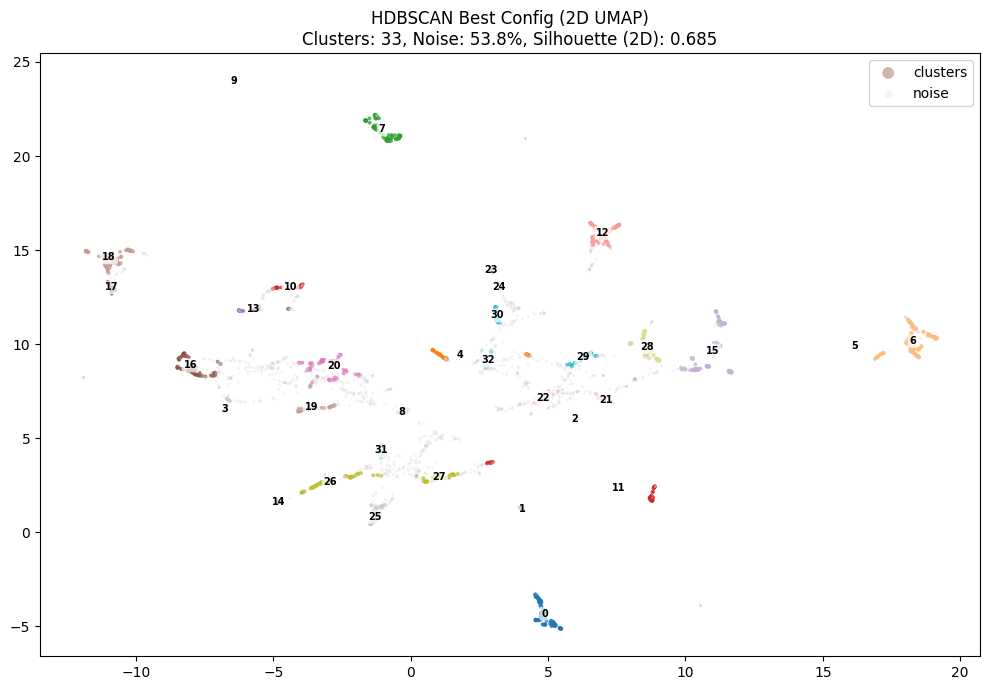

In [15]:
# ============================================
# 15. Optional 2D visualization of clusters (UMAP)
# ============================================
# Subsample for faster plotting on large datasets.
plot_df = df.copy()
plot_X = X_final.copy()

if len(plot_df) > VIS_SAMPLE_SIZE:
    sampled_idx = np.random.RandomState(RANDOM_STATE).choice(
        len(plot_df), size=VIS_SAMPLE_SIZE, replace=False
    )
    plot_df = plot_df.iloc[sampled_idx].reset_index(drop=True)
    plot_X = plot_X[sampled_idx]

# 2D UMAP projection for visualization
umap2d = umap.UMAP(
    n_components=2,
    metric="cosine",
    random_state=RANDOM_STATE
).fit_transform(plot_X)

plot_labels = plot_df["cluster"].to_numpy()
mask = plot_labels != -1

fig, ax = plt.subplots(figsize=(10, 7))
ax.scatter(
    umap2d[mask, 0],
    umap2d[mask, 1],
    c=plot_labels[mask],
    cmap="tab20",
    s=8,
    alpha=0.75,
    linewidths=0,
    rasterized=True,
    label="clusters",
)
ax.scatter(
    umap2d[~mask, 0],
    umap2d[~mask, 1],
    c="lightgray",
    s=4,
    alpha=0.25,
    linewidths=0,
    rasterized=True,
    label="noise",
)

# Annotate cluster centroids to make the groups easier to read.
for cluster_id in sorted(c for c in np.unique(plot_labels) if c != -1):
    cluster_mask = plot_labels == cluster_id
    if cluster_mask.sum() == 0:
        continue
    centroid = umap2d[cluster_mask].mean(axis=0)
    ax.text(
        centroid[0],
        centroid[1],
        str(cluster_id),
        fontsize=7,
        fontweight="bold",
        ha="center",
        va="center",
        bbox=dict(boxstyle="round,pad=0.2", facecolor="white", edgecolor="none", alpha=0.7),
)

sil_2d = (
    silhouette_score(umap2d[mask], plot_labels[mask])
    if mask.sum() > 1 and len(np.unique(plot_labels[mask])) > 1
    else np.nan
)
n_clusters_plot = int(len(set(plot_labels) - {-1}))
noise_pct_plot = float((~mask).mean() * 100)

sil_text = f"{sil_2d:.3f}" if not np.isnan(sil_2d) else "n/a"
ax.set_title(
    "HDBSCAN Best Config (2D UMAP)\n"
    f"Clusters: {n_clusters_plot}, Noise: {noise_pct_plot:.1f}%, Silhouette (2D): {sil_text}"
)
ax.legend(markerscale=3)
plt.tight_layout()
plt.show()

In [16]:
# ============================================
# 16. Optional: Save outputs
# ============================================
df.to_csv("twitter_hdbscan_clustered.csv", index=False)
summary_df.to_csv("twitter_hdbscan_cluster_summary.csv", index=False)
results_df.to_csv("twitter_hdbscan_param_search.csv", index=False)

print("Saved:")
print("- twitter_hdbscan_clustered.csv")
print("- twitter_hdbscan_cluster_summary.csv")
print("- twitter_hdbscan_param_search.csv")

Saved:
- twitter_hdbscan_clustered.csv
- twitter_hdbscan_cluster_summary.csv
- twitter_hdbscan_param_search.csv
